In [ ]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
DATASET_PATH = "/Users/elavarasan/Downloads/Projects/animal_classification/dataset"

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)

Found 1561 images belonging to 15 classes.
Found 383 images belonging to 15 classes.
Classes: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 182ms/step - accuracy: 0.4984 - loss: 1.9887 - val_accuracy: 0.8956 - val_loss: 1.2010
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 19s 190ms/step - accuracy: 0.8738 - loss: 0.8895 - val_accuracy: 0.9399 - val_loss: 0.5778
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.9180 - loss: 0.5019 - val_accuracy: 0.9399 - val_loss: 0.3756
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.9462 - loss: 0.3284 - val_accuracy: 0.9478 - val_loss: 0.2874
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - accuracy: 0.9488 - loss: 0.2674 - val_accuracy: 0.9582 - val_loss: 0.2435
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step - accuracy: 0.9622 - loss: 0.2069 - val_accuracy: 0.9582 - val_loss: 0.2179
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.9609 - loss: 0.1797 - val_accuracy: 0.9608 - val_loss: 0.2000
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - accuracy: 0.9705 - loss: 0.1548 - val_accu

In [ ]:
for layer in base_model.layers[-100:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 37s 305ms/step - accuracy: 0.9161 - loss: 0.4385 - val_accuracy: 0.9582 - val_loss: 0.1910
Epoch 2/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 32s 323ms/step - accuracy: 0.9308 - loss: 0.3646 - val_accuracy: 0.9504 - val_loss: 0.2172
Epoch 3/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 396ms/step - accuracy: 0.9443 - loss: 0.2975 - val_accuracy: 0.9478 - val_loss: 0.2241
Epoch 4/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 48s 486ms/step - accuracy: 0.9590 - loss: 0.2364 - val_accuracy: 0.9504 - val_loss: 0.2186
Epoch 5/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 44s 445ms/step - accuracy: 0.9564 - loss: 0.2229 - val_accuracy: 0.9556 - val_loss: 0.2105
Epoch 6/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 418ms/step - accuracy: 0.9699 - loss: 0.1699 - val_accuracy: 0.9582 - val_loss: 0.2019
Epoch 7/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 423ms/step - accuracy: 0.9648 - loss: 0.1721 - val_accuracy: 0.9608 - val_loss: 0.1951
Epoch 8/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 427ms/step - accuracy: 0.9763 - loss: 0.1413 - val_accu

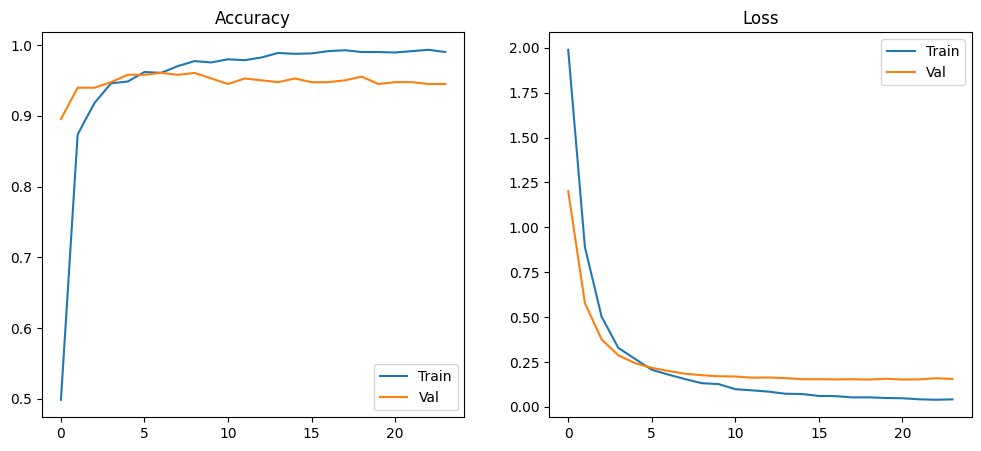

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
val_loss, val_acc = model.evaluate(val_data)

print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.9687 - loss: 0.1555
Validation Accuracy: 0.9686684012413025
Validation Loss: 0.15552936494350433


In [ ]:
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step
              precision    recall  f1-score   support

        Bear       1.00      0.96      0.98        25
        Bird       1.00      1.00      1.00        27
         Cat       0.96      0.96      0.96        24
         Cow       0.89      0.96      0.93        26
        Deer       0.92      0.96      0.94        25
         Dog       1.00      0.92      0.96        24
     Dolphin       1.00      1.00      1.00        25
    Elephant       0.93      1.00      0.96        26
     Giraffe       0.96      1.00      0.98        25
       Horse       1.00      0.88      0.94        26
    Kangaroo       0.96      0.92      0.94        25
        Lion       0.96      0.96      0.96        26
       Panda       0.96      1.00      0.98        27
       Tiger       1.00      1.00      1.00        25
       Zebra       1.00      1.00      1.00        27

    accuracy                           0.97       383
   macro avg       0.97      0.97      

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0]

    top3 = pred.argsort()[-3:][::-1]

    print("Top Predictions:")
    for i in top3:
        print(f"{class_names[i]} : {pred[i]*100:.2f}%")

In [ ]:
def predict_image_display(img_path):
    img = image.load_img(img_path, target_size=(224,224))

    plt.imshow(img)
    plt.axis("off")

    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0]
    top3 = pred.argsort()[-3:][::-1]

    title_text = ""

    print("Top Predictions:")
    for i in top3:
        result = f"{class_names[i]} : {pred[i]*100:.2f}%"
        print(result)
        title_text += result + "\n"

    plt.title(title_text)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Top Predictions:
Cat : 99.96%
Zebra : 0.01%
Dog : 0.01%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Top Predictions:
Tiger : 99.87%
Lion : 0.10%
Zebra : 0.01%


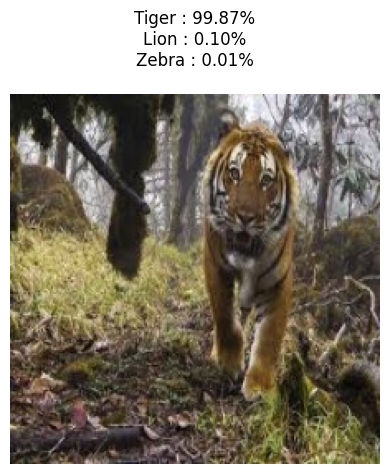

In [ ]:
predict_image(val_data.filepaths[67])

predict_image_display(val_data.filepaths[344])

In [ ]:
feature_model = Model(
    inputs=model.input,
    outputs=model.layers[-2].output   # remove final softmax layer
)

In [ ]:
image_features = []
image_paths = []

for img_path in val_data.filepaths:
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    features = feature_model.predict(img_array, verbose=0)
    
    image_features.append(features.flatten())
    image_paths.append(img_path)

image_features = np.array(image_features)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_images(query_img_path, top_n=5):
    # Load query image
    img = tf.keras.preprocessing.image.load_img(query_img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Extract features
    query_features = feature_model.predict(img_array, verbose=0).flatten()

    # Compute similarity
    similarities = cosine_similarity([query_features], image_features)[0]

    # Get top matches
    top_indices = similarities.argsort()[-top_n:][::-1]

    similar_images = [(image_paths[i], similarities[i]) for i in top_indices]

    return similar_images

In [ ]:
import matplotlib.pyplot as plt

def show_similar_images(query_img_path):
    similar_images = find_similar_images(query_img_path)

    plt.figure(figsize=(15,5))

    # Show query image
    plt.subplot(1,6,1)
    img = tf.keras.preprocessing.image.load_img(query_img_path)
    plt.imshow(img)
    plt.title("Query")
    plt.axis("off")

    # Show similar images
    for i, (path, score) in enumerate(similar_images):
        plt.subplot(1,6,i+2)
        img = tf.keras.preprocessing.image.load_img(path)
        plt.imshow(img)
        plt.title(f"{score:.2f}")
        plt.axis("off")

    plt.show()

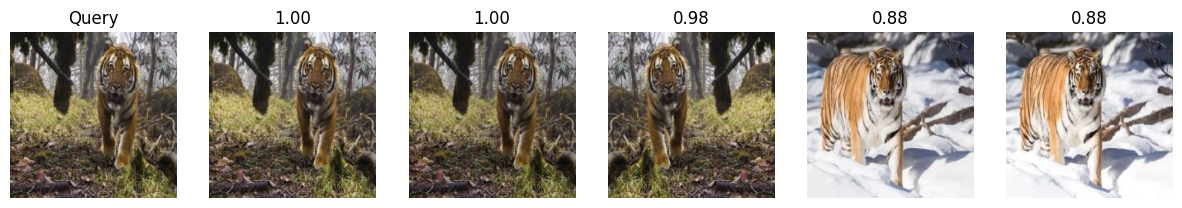

In [ ]:
query_image = val_data.filepaths[344]

show_similar_images(query_image)